# LangGraph + Groq Chatbot

A simple LangGraph chatbot using Groq's LLM through `ChatGroq`.

## 1. Install required packages

Run this cell once in the notebook environment.

In [1]:
!pip install -U langgraph langchain-core langchain-groq python-dotenv

Defaulting to user installation because normal site-packages is not writeable


## 2. Set up the Groq API key

Create a `.env` file in the same folder as this notebook with:

`GROQ_API_KEY=your_groq_api_key_here`

Do not share or commit your API key.

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY is not set. Add it to your .env file.")

print("Groq API key loaded successfully.")

ValueError: GROQ_API_KEY is not set. Add it to your .env file.

## 3. Import LangGraph and LangChain components

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq

from langgraph.graph.message import add_messages

C:\Users\Asus\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Define Chat State

The `add_messages` reducer maintains the message list by merging new messages into the existing state.

In [ ]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

## 5. Initialize Groq LLM

In [ ]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile-instruct",
    temperature=0
)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.14'}}, client=<groq.resources.chat.completions.Completions object at 0x00000224D5E97B60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000224D600C6E0>, model_name='llama-3.3-70b-versatile-instruct', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

## 6. Create Chat Node

The node takes the messages from the current graph state, sends them to Groq, and returns the AI response to the state.

In [ ]:
def chat_node(state: ChatState):
    # Take user query from state
    messages = state["messages"]

    # Send messages to Groq LLM
    response = llm.invoke(messages)

    # Store response back into state
    return {
        "messages": [response]
    }

## 7. Create State Graph

In [ ]:
graph = StateGraph(ChatState)

## 8. Add Nodes and Edges

The flow is:

`START → chat_node → END`

In [ ]:
# Add node
graph.add_node("chat_node", chat_node)

# Add edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

## 9. Compile Graph

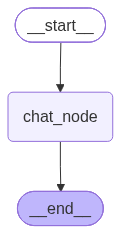

In [ ]:
chatbot = graph.compile()

chatbot

## 10. Initial State

Send the first user message to the graph.

In [ ]:
initial_state = {
    "messages": [
        HumanMessage(content="What is the capital of India?")
    ]
}
chatbot.invoke(initial_state)['messages'][-1].content

## 11. Invoke Chatbot

## 12. Inspect Complete State

This shows both the human message and the AI response.

## Important

This notebook uses the `add_messages` reducer, but it does **not** yet use LangGraph persistence/checkpointing. The reducer controls how messages are merged into the current graph state; persistence is what allows state to be saved and recovered across separate invocations.